# Regime-Based ETF Allocation: Building the Market Data Pipeline

This notebook prepares the dataset for a regime-based allocation strategy that rotates among TLT, GLD, and SPY depending on the volatility environment measured through VIX.

The pipeline covers:

1. Download adjusted close prices from Yahoo Finance.
2. Keep the maximum common sample where all four series are available.
3. Compute daily ETF log returns.
4. Compute the daily change in VIX.
5. Run simple checks and plots before moving on to modelling.

For later backtesting, a 1-day execution lag will be used to avoid lookahead bias. That lag is not applied here because this step only prepares the data.


## 1. Import Libraries

We keep the imports standard and light. `yfinance` is used only to download the market data, and the rest is regular data cleaning and plotting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Download Adjusted Close Prices

We download daily prices for TLT, GLD, SPY, and VIX from Yahoo Finance. The VIX ticker on Yahoo is `^VIX`. We use adjusted close prices for the ETFs so the returns account for distributions and corporate actions. For VIX, adjusted close and close are effectively the same index level.


In [2]:
tickers = ["TLT", "GLD", "SPY", "^VIX"]

raw_yahoo_data = yf.download(
    tickers,
    period="max",
    auto_adjust=False,
    progress=False,
)

# yfinance returns a multi-level column index. We only need adjusted close prices.
adjusted_close = raw_yahoo_data["Adj Close"].copy()
adjusted_close = adjusted_close.rename(columns={"^VIX": "VIX"})
adjusted_close = adjusted_close[["TLT", "GLD", "SPY", "VIX"]]

print(f"Downloaded rows before alignment: {len(adjusted_close):,}")
display(adjusted_close.head())
display(adjusted_close.tail())

Downloaded rows before alignment: 9,161


Ticker,TLT,GLD,SPY,VIX
Date,,,,
1990-01-02,NaN,NaN,NaN,17.240000
1990-01-03,NaN,NaN,NaN,18.190001
1990-01-04,NaN,NaN,NaN,19.219999
1990-01-05,NaN,NaN,NaN,20.110001
1990-01-08,NaN,NaN,NaN,20.260000


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2026-05-12,84.989998,432.929993,738.179993,17.990000
2026-05-13,84.800003,430.500000,742.309998,17.870001
2026-05-14,84.919998,427.209991,748.169983,17.260000
2026-05-15,83.660004,417.290009,739.169983,18.430000
2026-05-18,NaN,NaN,NaN,18.570000


## 3. Align on the Common Sample Period

The assets did not all start trading on the same date. To keep the analysis clean, we drop dates where any of the four series is missing. This gives the maximum common sample period across TLT, GLD, SPY, and VIX.


In [3]:
common_prices = adjusted_close.dropna().copy()

common_price_summary = pd.DataFrame({
    "Item": ["First common date", "Last common date", "Number of price observations"],
    "Value": [
        common_prices.index.min().strftime("%Y-%m-%d"),
        common_prices.index.max().strftime("%Y-%m-%d"),
        f"{len(common_prices):,}",
    ],
})

display(common_price_summary)
display(common_prices.head())
display(common_prices.tail())

,Item,Value
0,First common date,2004-11-18
1,Last common date,2026-05-15
2,Number of price observations,"5,406"


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2004-11-18,44.161694,44.380001,79.950691,12.980000
2004-11-19,43.809265,44.779999,79.061882,13.500000
2004-11-22,44.037582,44.950001,79.438980,12.970000
2004-11-23,44.092155,44.750000,79.560204,12.670000
2004-11-24,44.092155,45.049999,79.748665,12.720000


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2026-05-11,85.559998,434.649994,739.299988,18.379999
2026-05-12,84.989998,432.929993,738.179993,17.990000
2026-05-13,84.800003,430.500000,742.309998,17.870001
2026-05-14,84.919998,427.209991,748.169983,17.260000
2026-05-15,83.660004,417.290009,739.169983,18.430000


## 4. Compute Returns and Daily VIX Changes

For TLT, GLD, and SPY, we compute daily log returns. For VIX, we compute the daily level change:

`Delta_VIX = VIX_t - VIX_{t-1}`

This keeps the ETF return inputs and the volatility-regime input in one aligned table.


In [4]:
etf_tickers = ["TLT", "GLD", "SPY"]

etf_log_returns = np.log(common_prices[etf_tickers] / common_prices[etf_tickers].shift(1))
etf_log_returns = etf_log_returns.rename(columns={
    "TLT": "TLT_log_return",
    "GLD": "GLD_log_return",
    "SPY": "SPY_log_return",
})

delta_vix = common_prices["VIX"].diff().rename("Delta_VIX")

strategy_data = pd.concat([etf_log_returns, delta_vix], axis=1).dropna()

display(strategy_data.head())
display(strategy_data.tail())

,TLT_log_return,GLD_log_return,SPY_log_return,Delta_VIX
Date,,,,
2004-11-19,-0.008012,0.008973,-0.011179,0.520000
2004-11-22,0.005198,0.003789,0.004758,-0.530000
2004-11-23,0.001238,-0.004459,0.001525,-0.300000
2004-11-24,0.000000,0.006682,0.002366,0.050000
2004-11-26,-0.006550,0.005313,-0.000760,0.059999


,TLT_log_return,GLD_log_return,SPY_log_return,Delta_VIX
Date,,,,
2026-05-11,-0.006059,0.002027,0.002275,1.189999
2026-05-12,-0.006684,-0.003965,-0.001516,-0.389999
2026-05-13,-0.002238,-0.005629,0.005579,-0.119999
2026-05-14,0.001414,-0.007672,0.007863,-0.610001
2026-05-15,-0.014949,-0.023494,-0.012102,1.170000


## 5. Data Quality Checks

Before using the data in a strategy, we check the final date range, number of observations, and missing values. This makes it easier to catch alignment problems early.


In [5]:
step1_data_summary = pd.DataFrame({
    "Item": ["First return date", "Last return date", "Number of aligned observations"],
    "Value": [
        strategy_data.index.min().strftime("%Y-%m-%d"),
        strategy_data.index.max().strftime("%Y-%m-%d"),
        f"{len(strategy_data):,}",
    ],
})

missing_value_check = strategy_data.isna().sum().to_frame("Missing Values")

display(step1_data_summary)
display(missing_value_check)

,Item,Value
0,First return date,2004-11-19
1,Last return date,2026-05-15
2,Number of aligned observations,"5,405"


,Missing Values
TLT_log_return,0
GLD_log_return,0
SPY_log_return,0
Delta_VIX,0


## 6. Plot ETF Returns Over Time

The return plots help us see volatility clustering and stress periods. Daily returns are naturally noisy, so the main thing to look for is when the size of the moves becomes unusually large.


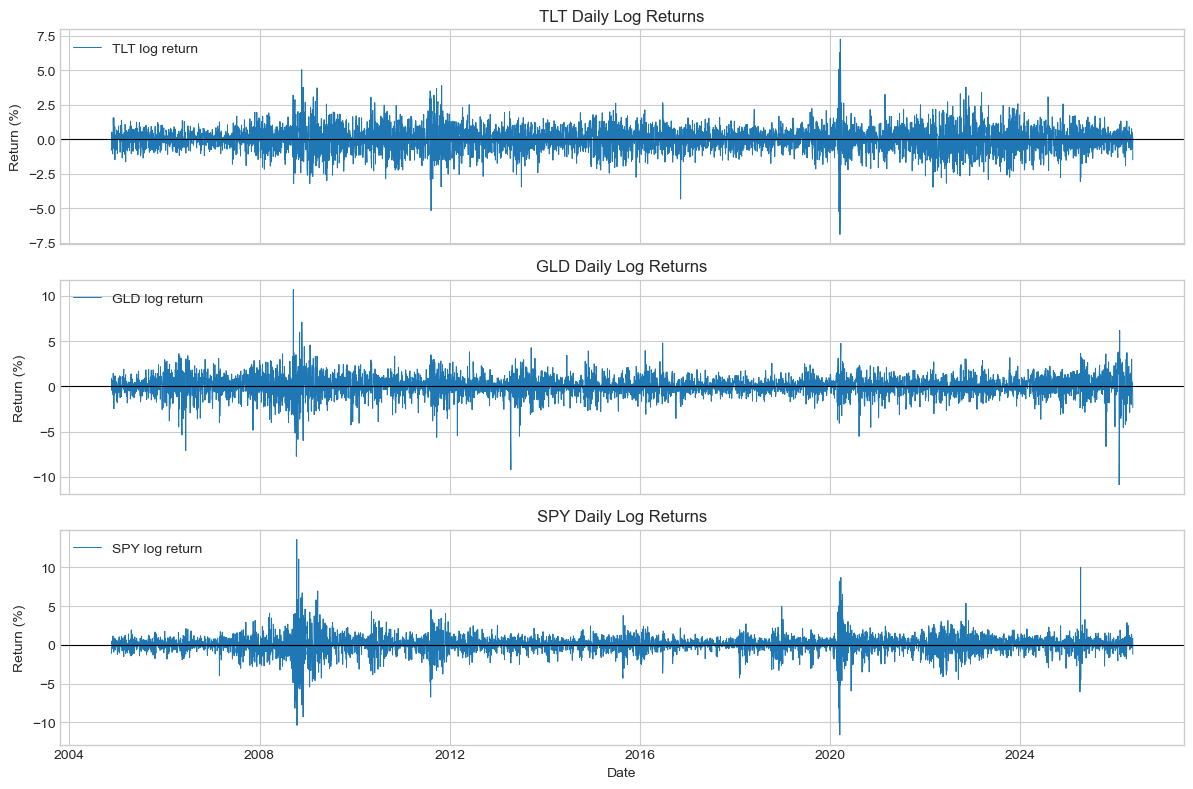

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

return_columns = ["TLT_log_return", "GLD_log_return", "SPY_log_return"]
plot_titles = ["TLT Daily Log Returns", "GLD Daily Log Returns", "SPY Daily Log Returns"]

for ax, column, title in zip(axes, return_columns, plot_titles):
    ax.plot(strategy_data.index, 100 * strategy_data[column], linewidth=0.7, label=column.replace("_", " "))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Return (%)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 7. Plot Daily VIX Changes

VIX changes are the volatility-regime input for the later allocation strategy. Large positive values usually mean market volatility increased quickly, while negative values mean volatility eased.


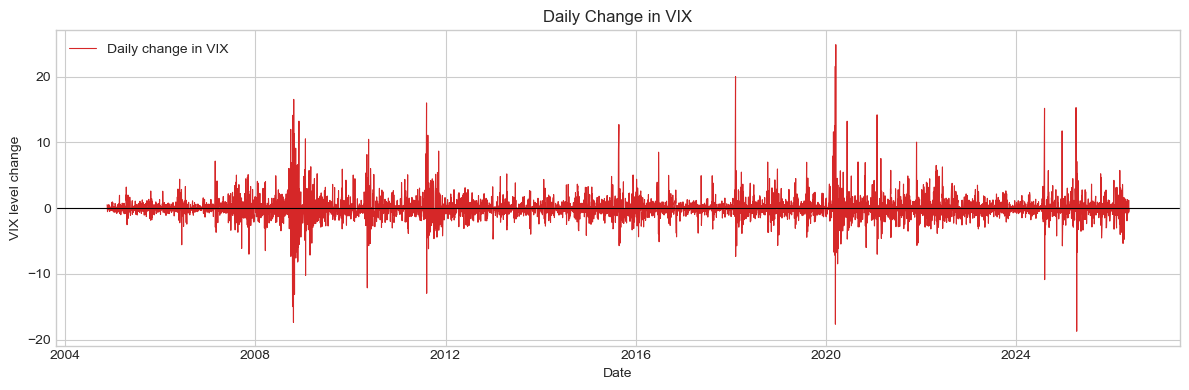

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(strategy_data.index, strategy_data["Delta_VIX"], linewidth=0.8, color="tab:red", label="Daily change in VIX")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Daily Change in VIX")
ax.set_xlabel("Date")
ax.set_ylabel("VIX level change")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# SM Group Work Project 2 M7 (Group 14912)

This notebook walks through how we built the dataset and investment strategy for our regime-based asset allocation project. The whole idea here is to rotate our money between long-term Treasuries (TLT), Gold (GLD), and the S&P 500 (SPY) based on how volatile the market is feeling which we'll figure out by looking at the VIX.

# Step 1: Data Preparation and Exploration

We need to get everything clean and reliable before throwing models at it:

1. Get the adjusted close prices directly from Yahoo Finance.
2. Align the dates so we're only looking at days when all four tickers actually traded.
3. Calculate the daily log returns for our three asset ETFs.
4. Track the absolute daily change in the VIX level.
5. Double-check for missing data and throw up some quick plots to make sure everything looks right.

*Note for later:* The 1-day execution lag is going to be a big deal when we backtest this strategy so we aren't cheating, but for right now, let's just focus on getting the data properly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Using a clean style for the plots and forcing pandas to show 6 decimal places 
# so we don't lose track of tiny return differences.
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Pulling the Adjusted Close Prices

We're downloading the daily price histories for TLT, GLD, SPY, and the VIX from Yahoo Finance (where the VIX uses the `^VIX` ticker symbol). 

For the asset ETFs, using the *Adjusted Close* is important because it accounts for dividends and corporate actions automatically. For the VIX, the index level is the index level, so close and adjusted close are basically identical.

*NB:* We're stopping the download right at `2026-05-16`, meaning our last actual trading day in the sample is Friday, `2026-05-15`. So the numbers stay exactly the same every time we re-run this notebook.

In [ ]:
tickers = ["TLT", "GLD", "SPY", "^VIX"]

raw_yahoo_data = yf.download(
    tickers,
    start="1990-01-01",
    end="2026-05-16",
    auto_adjust=False,
    progress=False,
)

# Yahoo returns a lot of columns, so let's filter out everything except 'Adj Close'
adjusted_close = raw_yahoo_data["Adj Close"].copy()
adjusted_close = adjusted_close.rename(columns={"^VIX": "VIX"})
adjusted_close = adjusted_close[["TLT", "GLD", "SPY", "VIX"]]

print(f"Rows downloaded before alignment: {len(adjusted_close):,}")
display(adjusted_close.head())
display(adjusted_close.tail())

Rows downloaded before alignment: 9,160


Ticker,TLT,GLD,SPY,VIX
Date,,,,
1990-01-02,NaN,NaN,NaN,17.240000
1990-01-03,NaN,NaN,NaN,18.190001
1990-01-04,NaN,NaN,NaN,19.219999
1990-01-05,NaN,NaN,NaN,20.110001
1990-01-08,NaN,NaN,NaN,20.260000


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2026-05-11,85.559998,434.649994,739.299988,18.379999
2026-05-12,84.989998,432.929993,738.179993,17.990000
2026-05-13,84.800003,430.500000,742.309998,17.870001
2026-05-14,84.919998,427.209991,748.169983,17.260000
2026-05-15,83.660004,417.290009,739.169983,18.430000


## 3. Lining Up the Dates (Finding the Common Sample Period)

Since these ETFs launched at totally different times (SPY is way older than GLD and TLT), we have a lot of `NaN` values in the early years. To fix this, we're dropping any row with missing data. This gives us one perfectly synced timeline where all four market series live together.

In [ ]:
# Drp all rows with NaNs to find the exact day they all started existing together
common_prices = adjusted_close.dropna().copy()

common_price_summary = pd.DataFrame({
    "Item": ["First common date", "Last common date", "Number of price observations"],
    "Value": [
        common_prices.index.min().strftime("%Y-%m-%d"),
        common_prices.index.max().strftime("%Y-%m-%d"),
        f"{len(common_prices):,}",
    ],
})

display(common_price_summary)
display(common_prices.head())
display(common_prices.tail())

,Item,Value
0,First common date,2004-11-18
1,Last common date,2026-05-15
2,Number of price observations,"5,406"


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2004-11-18,44.161674,44.380001,79.950722,12.980000
2004-11-19,43.809258,44.779999,79.061928,13.500000
2004-11-22,44.037579,44.950001,79.438965,12.970000
2004-11-23,44.092186,44.750000,79.560188,12.670000
2004-11-24,44.092186,45.049999,79.748703,12.720000


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2026-05-11,85.559998,434.649994,739.299988,18.379999
2026-05-12,84.989998,432.929993,738.179993,17.990000
2026-05-13,84.800003,430.500000,742.309998,17.870001
2026-05-14,84.919998,427.209991,748.169983,17.260000
2026-05-15,83.660004,417.290009,739.169983,18.430000


## 4. Calculating Daily Returns and VIX Shifts

Next up is the math. For our asset ETFs (TLT, GLD, SPY), we need to calculate daily log returns. 

For the VIX, we don't want percent returns. Volatility is already stated as a percentage, so we just want the simple, absolute day-to-day change in its level:
$$ \Delta VIX_t = VIX_t - VIX_{t-1} $$

Then we'll mash them all back together into a single, perfectly aligned dataframe.

In [ ]:
etf_tickers = ["TLT", "GLD", "SPY"]

etf_log_returns = np.log(common_prices[etf_tickers] / common_prices[etf_tickers].shift(1))
etf_log_returns = etf_log_returns.rename(columns={
    "TLT": "TLT_log_return",
    "GLD": "GLD_log_return",
    "SPY": "SPY_log_return",
})

delta_vix = common_prices["VIX"].diff().rename("Delta_VIX")

# Concat everything horizontally, and drop the very first row since it loses a day to the diff/shift
strategy_data = pd.concat([etf_log_returns, delta_vix], axis=1).dropna()

display(strategy_data.head())
display(strategy_data.tail())

,TLT_log_return,GLD_log_return,SPY_log_return,Delta_VIX
Date,,,,
2004-11-19,-0.008012,0.008973,-0.011179,0.520000
2004-11-22,0.005198,0.003789,0.004758,-0.530000
2004-11-23,0.001239,-0.004459,0.001525,-0.300000
2004-11-24,0.000000,0.006682,0.002367,0.050000
2004-11-26,-0.006551,0.005313,-0.000761,0.059999


,TLT_log_return,GLD_log_return,SPY_log_return,Delta_VIX
Date,,,,
2026-05-11,-0.006059,0.002027,0.002275,1.189999
2026-05-12,-0.006684,-0.003965,-0.001516,-0.389999
2026-05-13,-0.002238,-0.005629,0.005579,-0.119999
2026-05-14,0.001414,-0.007672,0.007863,-0.610001
2026-05-15,-0.014949,-0.023494,-0.012102,1.170000


## 5. Double-Checking Data Quality

So before throwing this data into a complicated model, let's do a quick quality assurance check. We need to verify our final date ranges, count the rows, and ensure absolutely zero missing (`NaN`) values slipped through. If things are misaligned here, our entire strategy down the road will be broken.

In [ ]:
# Summarizing the final shape of our returns data
step1_data_summary = pd.DataFrame({
    "Item": ["First return date", "Last return date", "Number of aligned observations"],
    "Value": [
        strategy_data.index.min().strftime("%Y-%m-%d"),
        strategy_data.index.max().strftime("%Y-%m-%d"),
        f"{len(strategy_data):,}",
    ],
})

missing_value_check = strategy_data.isna().sum().to_frame("Missing Values")

display(step1_data_summary)
display(missing_value_check)

,Item,Value
0,First return date,2004-11-19
1,Last return date,2026-05-15
2,Number of aligned observations,"5,405"


,Missing Values
TLT_log_return,0
GLD_log_return,0
SPY_log_return,0
Delta_VIX,0


## 6. Visualizing ETF Returns Over Time

Let's look at what we've built. These subplots display the daily log returns for all three ETFs. So daily market returns look like complete static noise, but looking at them this way makes it really easy to spot historical market panics.

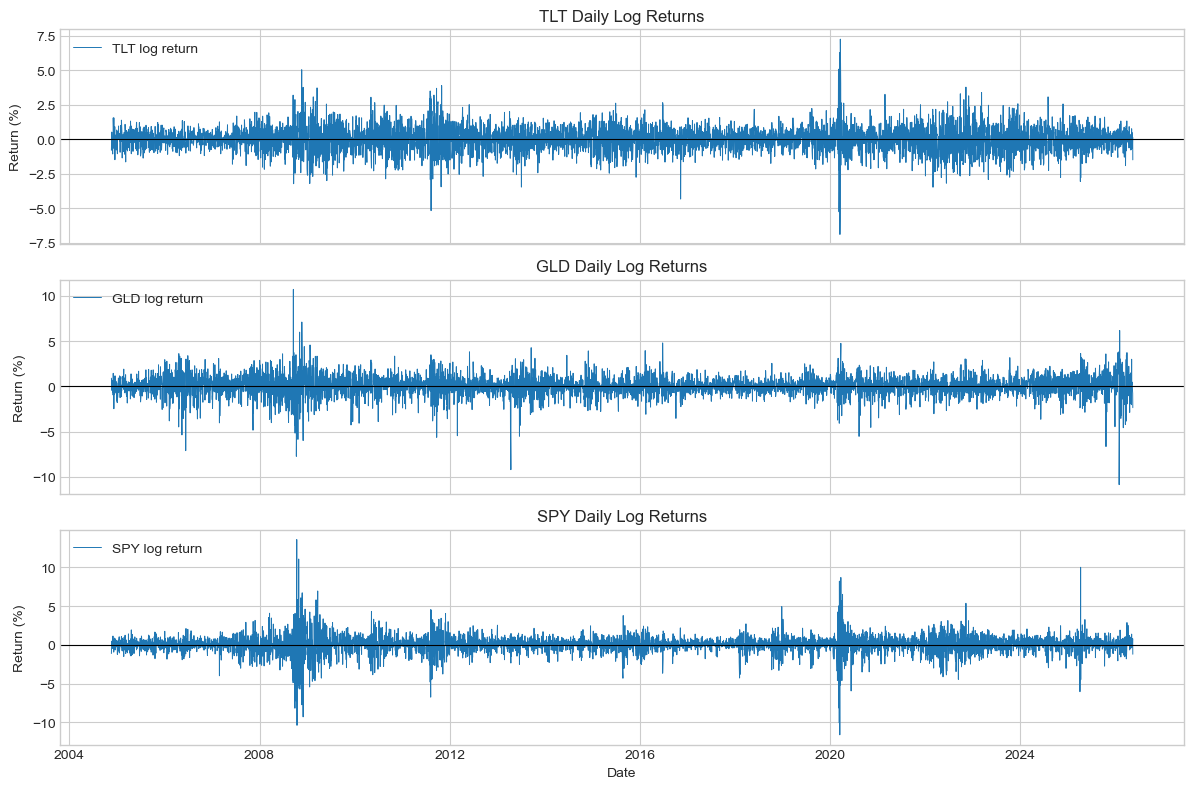

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

return_columns = ["TLT_log_return", "GLD_log_return", "SPY_log_return"]
plot_titles = ["TLT Daily Log Returns", "GLD Daily Log Returns", "SPY Daily Log Returns"]

# Looping through to generate the plots cleanly without repeating code
for ax, column, title in zip(axes, return_columns, plot_titles):
    ax.plot(strategy_data.index, 100 * strategy_data[column], linewidth=0.7, label=column.replace("_", " "))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Return (%)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 7. Visualizing Daily VIX Level Changes

Now let's check out the VIX changes. This chart shows how many points the fear index added or lost each day. Massive positive spikes show exactly when market panic exploded out of nowhere, while the subsequent negative dips show the market calming back down.

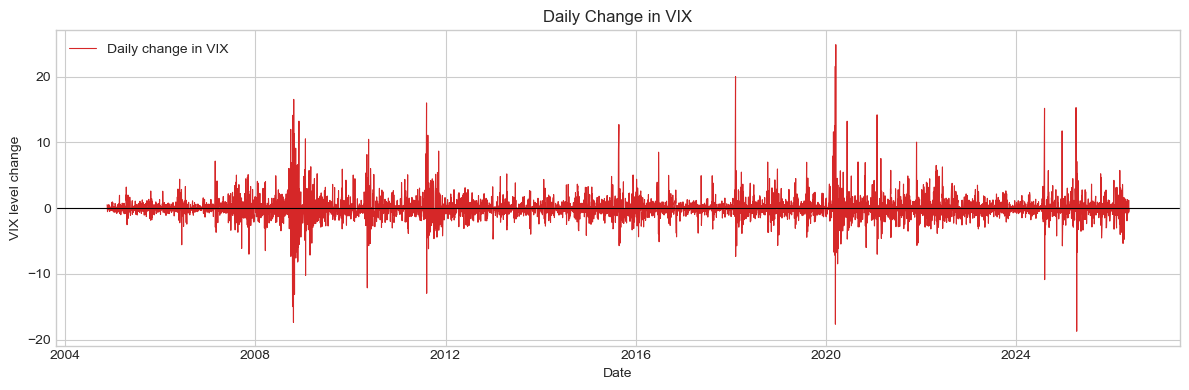

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plotting the VIX level shifts over time
ax.plot(strategy_data.index, strategy_data["Delta_VIX"], linewidth=0.8, color="tab:red", label="Daily change in VIX")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Daily Change in VIX")
ax.set_xlabel("Date")
ax.set_ylabel("VIX level change")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Interpretation of Step 1

The aligned dataset starts on November 19, 2004, which is the first return date where all four series are available together. After computing ETF log returns and daily VIX changes, our final dataset contains 5,405 observations with no missing values.

The ETF return plots show the usual noise in daily returns, while the Delta VIX plot shows clear volatility spikes around market stress periods. This supports the idea of using VIX behavior to identify different volatility environments.

# Step 2: Modeling VIX Regimes

Now that our data is clean, we can start the machine learning piece. We are going to use a Gaussian HMM to group our daily VIX shifts (`Delta_VIX`) into distinct market environments or "regimes". The core theory here is that VIX changes behave entirely differently when the market is relaxed versus when it's crashing.

To see what structure fits best, we are going to train and compare two separate models:
1. A simple 2-state HMM (i.e Calm vs. Stressed).
2. A more nuanced 3-state HMM (i.e Calm, Normal, and Stressed).

The script uses the Expectation-Maximization (EM) algorithm under the hood to find these states, and we'll fix the random seeds so our results don't bounce around on us.

In [ ]:
try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn is available, so we can fit the HMMs.")
except ModuleNotFoundError:
    print("hmmlearn is not installed yet. Run this in a notebook cell: %pip install hmmlearn")
    raise

hmmlearn is available, so we can fit the HMMs.


## 2. Formatting the Inputs

The HMM only looks at our `Delta_VIX` column. The `hmmlearn` library requires a 2D numpy array format `(samples, features)`, so we'll get the values and reshape them into a column vector.

In [ ]:
# The HMM input is the daily change in VIX.
X = strategy_data[["Delta_VIX"]].values

print(f"Shape of the HMM input: {X.shape}")
strategy_data[["Delta_VIX"]].head()

Shape of the HMM input: (5405, 1)


,Delta_VIX
Date,
2004-11-19,0.520000
2004-11-22,-0.530000
2004-11-23,-0.300000
2004-11-24,0.050000
2004-11-26,0.059999


## 3. Building a State Sorting Function

When an HMM solves for hidden states, it assigns state numbers (like 0, 1, or 2) completely at random based on how the math initialized. To help us down the line, I wrote a quick helper function that automatically re-orders the states by their average `Delta_VIX` level. 

That way, across both models:
- **State 0** will *always* mean the lowest volatility-change environment (Calm).
- **State 1** will mean higher volatility (or the middle state for the 3-state model).
- **State 2** (in the 3-state version) will *always* represent the absolute highest volatility environment (Panic/Stressed).

In [ ]:
def fit_sorted_hmm(X, n_states, random_seed):
    """Fits a Gaussian HMM and remaps states so they are sorted by increasing mean volatility"""
    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=1000,
        tol=1e-4,
        random_state=random_seed,
    )

    # Triggering the EM algorithm to find the optimized parameters
    model.fit(X)

    log_likelihood = model.score(X)
    raw_states = model.predict(X)
    raw_probabilities = model.predict_proba(X)

    raw_means = model.means_.flatten()
    raw_stds = np.sqrt(np.array(model.covars_).reshape(n_states, -1)[:, 0])

    # Sorting our states by their means so State 0 is always lowest vol, State 1 is next, etc.
    sorted_order = np.argsort(raw_means)
    raw_to_sorted = {raw_state: sorted_state for sorted_state, raw_state in enumerate(sorted_order)}

    sorted_states = np.array([raw_to_sorted[state] for state in raw_states])
    sorted_means = raw_means[sorted_order]
    sorted_stds = raw_stds[sorted_order]
    sorted_transition_matrix = model.transmat_[np.ix_(sorted_order, sorted_order)]
    sorted_probabilities = raw_probabilities[:, sorted_order]

    return {
        "model": model,
        "log_likelihood": log_likelihood,
        "states": sorted_states,
        "probabilities": sorted_probabilities,
        "means": sorted_means,
        "stds": sorted_stds,
        "transition_matrix": sorted_transition_matrix,
    }

## 4. Running the HMM Fits

Let's execute the function we just wrote and fit both models. We will print out the final log likelihood scores to see how much explanatory power we gain by adding that third state.

In [ ]:
hmm_2 = fit_sorted_hmm(X, n_states=2, random_seed=622)
hmm_3 = fit_sorted_hmm(X, n_states=3, random_seed=623)

hmm_fit_summary = pd.DataFrame({
    "Model": ["2-State Gaussian HMM", "3-State Gaussian HMM"],
    "Number of States": [2, 3],
    "Log-Likelihood": [hmm_2["log_likelihood"], hmm_3["log_likelihood"]],
})

display(hmm_fit_summary)

,Model,Number of States,Log-Likelihood
0,2-State Gaussian HMM,2,"-9,208.277315"
1,3-State Gaussian HMM,3,"-8,864.003795"


## 5. Adding Regime Labels to our Dataframe

Now that the models have tagged every single trading day with a hidden state, let's map those arbitrary numbers to clean, descriptive text string labels and append them to our main dataframe. This will make backtesting a lot easier to read.

In [ ]:
hmm2_labels = {
    0: "Low / Calm",
    1: "High / Stressed",
}

hmm3_labels = {
    0: "Low / Calm",
    1: "Medium / Normal",
    2: "High / Stressed",
}

# Adding the regime labels to our main dataframe
strategy_data["HMM2_Regime"] = pd.Series(hmm_2["states"], index=strategy_data.index).map(hmm2_labels)
strategy_data["HMM3_Regime"] = pd.Series(hmm_3["states"], index=strategy_data.index).map(hmm3_labels)

strategy_data[["Delta_VIX", "HMM2_Regime", "HMM3_Regime"]].head()

,Delta_VIX,HMM2_Regime,HMM3_Regime
Date,,,
2004-11-19,0.520000,Low / Calm,Low / Calm
2004-11-22,-0.530000,Low / Calm,Low / Calm
2004-11-23,-0.300000,Low / Calm,Low / Calm
2004-11-24,0.050000,Low / Calm,Low / Calm
2004-11-26,0.059999,Low / Calm,Low / Calm


## 6. Examining the 2-State Model Parameters

So let's peer inside the 2-state model. This summary table breaks down the calculated average VIX shift, the standard deviation (how wild the moves are), and what percentage of total history spent its time in each state.

In [ ]:
hmm2_parameter_table = pd.DataFrame({
    "Sorted State": [0, 1],
    "Regime Label": [hmm2_labels[0], hmm2_labels[1]],
    "Delta_VIX Mean": hmm_2["means"],
    "Delta_VIX Std Dev": hmm_2["stds"],
    "Share of Days": [np.mean(hmm_2["states"] == state) for state in range(2)],
})

print(f"2-state HMM log-likelihood: {hmm_2['log_likelihood']:,.2f}")
display(hmm2_parameter_table)

2-state HMM log-likelihood: -9,208.28


,Sorted State,Regime Label,Delta_VIX Mean,Delta_VIX Std Dev,Share of Days
0,0,Low / Calm,-0.073705,0.811454,0.760962
1,1,High / Stressed,0.214391,3.473779,0.239038


## 7. Examining the 3-State Model Parameters

Now let's look at the 3-state parameters. This gives us a much more granular view of market transition, giving us a "bridge" state between smooth sailing and total panic.

In [ ]:
hmm3_parameter_table = pd.DataFrame({
    "Sorted State": [0, 1, 2],
    "Regime Label": [hmm3_labels[0], hmm3_labels[1], hmm3_labels[2]],
    "Delta_VIX Mean": hmm_3["means"],
    "Delta_VIX Std Dev": hmm_3["stds"],
    "Share of Days": [np.mean(hmm_3["states"] == state) for state in range(3)],
})

print(f"3-state HMM log-likelihood: {hmm_3['log_likelihood']:,.2f}")
display(hmm3_parameter_table)

3-state HMM log-likelihood: -8,864.00


,Sorted State,Regime Label,Delta_VIX Mean,Delta_VIX Std Dev,Share of Days
0,0,Low / Calm,-0.059885,0.620513,0.527475
1,1,Medium / Normal,-0.012967,1.759897,0.422942
2,2,High / Stressed,0.650673,6.024823,0.049584


## 8. Transition Matrices

The transition matrix tells us the probability of switching states. For instance, what's the chance that a "Calm" market today turns into a "Stressed" market tomorrow? High numbers along the diagonal mean the states are nice and persistent, which is exactly what we want for a trading strategy.

In [ ]:
hmm2_transition_matrix = pd.DataFrame(
    hmm_2["transition_matrix"],
    index=["From Low / Calm", "From High / Stressed"],
    columns=["To Low / Calm", "To High / Stressed"],
)

hmm3_transition_matrix = pd.DataFrame(
    hmm_3["transition_matrix"],
    index=["From Low / Calm", "From Medium / Normal", "From High / Stressed"],
    columns=["To Low / Calm", "To Medium / Normal", "To High / Stressed"],
)

print("2-state HMM transition matrix")
display(hmm2_transition_matrix)

print("3-state HMM transition matrix")
display(hmm3_transition_matrix)

2-state HMM transition matrix


,To Low / Calm,To High / Stressed
From Low / Calm,0.959238,0.040762
From High / Stressed,0.116364,0.883636


3-state HMM transition matrix


,To Low / Calm,To Medium / Normal,To High / Stressed
From Low / Calm,0.939953,0.059062,0.000984
From Medium / Normal,0.073868,0.909877,0.016255
From High / Stressed,0.000000,0.127501,0.872499


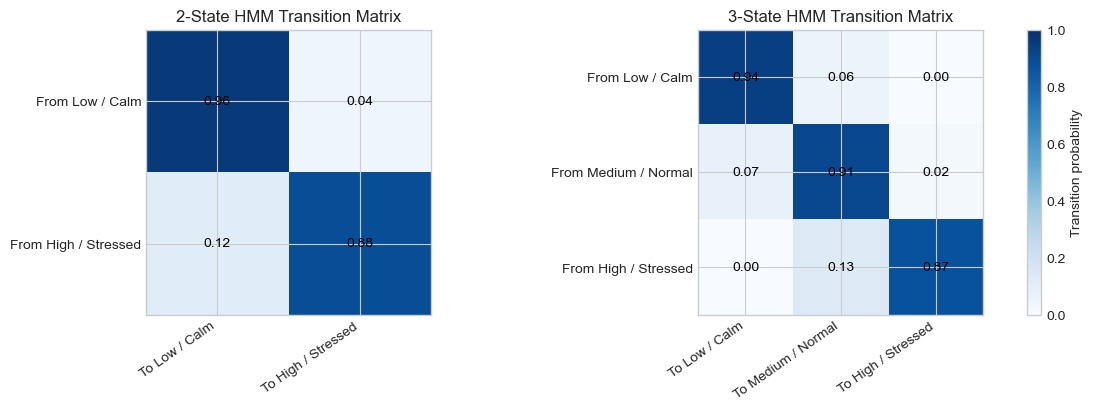

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

matrices = [hmm2_transition_matrix, hmm3_transition_matrix]
titles = ["2-State HMM Transition Matrix", "3-State HMM Transition Matrix"]

for ax, matrix, title in zip(axes, matrices, titles):
    image = ax.imshow(matrix.values, vmin=0, vmax=1, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
    ax.set_yticklabels(matrix.index)

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix.values[row, col]:.2f}", ha="center", va="center", color="black")

fig.colorbar(image, ax=axes, fraction=0.03, pad=0.04, label="Transition probability")
plt.show()

## 9. Checking Posterior Probabilities

The posterior probabilities show how confident our model is on any given day.

In [ ]:
hmm2_posterior = pd.DataFrame(
    hmm_2["probabilities"],
    index=strategy_data.index,
    columns=["Prob Low / Calm", "Prob High / Stressed"],
)

hmm3_posterior = pd.DataFrame(
    hmm_3["probabilities"],
    index=strategy_data.index,
    columns=["Prob Low / Calm", "Prob Medium / Normal", "Prob High / Stressed"],
)

print("2-state posterior probabilities, first five rows")
display(hmm2_posterior.head())

print("3-state posterior probabilities, first five rows")
display(hmm3_posterior.head())

2-state posterior probabilities, first five rows


,Prob Low / Calm,Prob High / Stressed
Date,,
2004-11-19,1.000000,0.000000
2004-11-22,0.998237,0.001763
2004-11-23,0.998033,0.001967
2004-11-24,0.998001,0.001999
2004-11-26,0.997900,0.002100


3-state posterior probabilities, first five rows


,Prob Low / Calm,Prob Medium / Normal,Prob High / Stressed
Date,,,
2004-11-19,1.000000,0.000000,0.000000
2004-11-22,0.996547,0.003452,0.000001
2004-11-23,0.995897,0.004102,0.000001
2004-11-24,0.995709,0.004289,0.000001
2004-11-26,0.995270,0.004729,0.000002


## 10. Plotting VIX Shifts Colored by the 2-State Regimes

Let's visualize how the 2-state HMM separated the data.

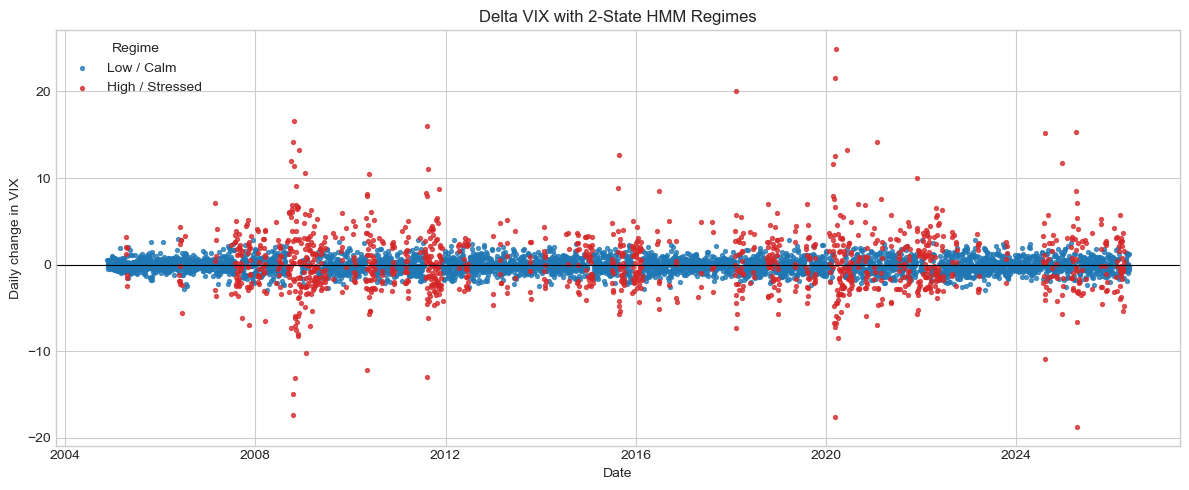

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

hmm2_colors = {
    "Low / Calm": "tab:blue",
    "High / Stressed": "tab:red",
}

# Subsetting and scatter plotting each state separately to apply the custom colors
for label, color in hmm2_colors.items():
    subset = strategy_data[strategy_data["HMM2_Regime"] == label]
    ax.scatter(subset.index, subset["Delta_VIX"], s=8, color=color, label=label, alpha=0.75)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Delta VIX with 2-State HMM Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("Daily change in VIX")
ax.legend(title="Regime", loc="upper left")
plt.tight_layout()
plt.show()

## 11. Plotting VIX Shifts Colored by the 3-State Regimes

Let's do the exact same thing for the 3-state HMM. This lets us visualize how the model split out that middle, intermediate "Normal" market environment (shown in orange).

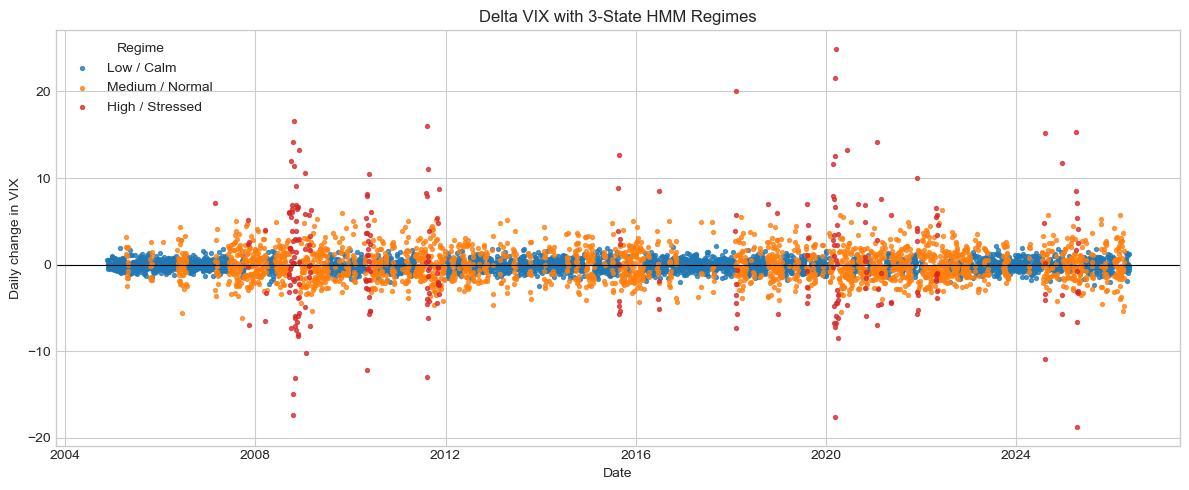

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

hmm3_colors = {
    "Low / Calm": "tab:blue",
    "Medium / Normal": "tab:orange",
    "High / Stressed": "tab:red",
}

# Mapping the 3-state scatter plot
for label, color in hmm3_colors.items():
    subset = strategy_data[strategy_data["HMM3_Regime"] == label]
    ax.scatter(subset.index, subset["Delta_VIX"], s=8, color=color, label=label, alpha=0.75)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Delta VIX with 3-State HMM Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("Daily change in VIX")
ax.legend(title="Regime", loc="upper left")
plt.tight_layout()
plt.show()

## Interpretation of Step 2

The two HMM specifications give different levels of detail. In the 2-state model, most days are classified as Low / Calm, while the High / Stressed state has a higher average Delta VIX and much larger dispersion.

The 3-state model gives a more detailed split. It separates the sample into Low / Calm, Medium / Normal, and High / Stressed regimes. The stressed state is much smaller, but it captures the largest VIX moves. The transition matrices also show persistence, which means regimes tend to last for some time rather than switching randomly every day.

# Step 3: State Selection and Interpretation

Now we have to make a choice. We've got our 2-state and 3-state frameworks, so let's run some formal statistical metrics (AIC and BIC) to see which model behaves best. 

Beyond just the raw statistics, we also need to look at the real-world performance of our ETFs inside these hidden states to see if the asset rotation logic actually makes sense.

## 1. Comparing the Models via AIC and BIC

We're going to compute the AIC and BIC for both models. These metrics reward a better statistical fit, but they punish models that use too many parameters. Lower numbers mean a more efficient model

*NB:* For a 1D Gaussian HMM, the total parameter count is calculated as:
$$k = N \times (N - 1) + (N - 1) + 2N$$
where $N$ is our number of hidden states.

In [ ]:
def hmm_parameter_count(n_states):
    # Summing up transition probabilities, initial states, and the Gaussian means/variances
    transition_parameters = n_states * (n_states - 1)
    initial_state_parameters = n_states - 1
    gaussian_parameters = 2 * n_states
    return transition_parameters + initial_state_parameters + gaussian_parameters

n_observations = len(strategy_data)

model_comparison = pd.DataFrame({
    "Model": ["2-State Gaussian HMM", "3-State Gaussian HMM"],
    "Number of States": [2, 3],
    "Log-Likelihood": [hmm_2["log_likelihood"], hmm_3["log_likelihood"]],
})

# Calculating the formal criteria scores
model_comparison["Number of Parameters"] = model_comparison["Number of States"].apply(hmm_parameter_count)
model_comparison["AIC"] = 2 * model_comparison["Number of Parameters"] - 2 * model_comparison["Log-Likelihood"]
model_comparison["BIC"] = (
    model_comparison["Number of Parameters"] * np.log(n_observations)
    - 2 * model_comparison["Log-Likelihood"]
)

model_comparison

,Model,Number of States,Log-Likelihood,Number of Parameters,AIC,BIC
0,2-State Gaussian HMM,2,"-9,208.277315",7,"18,430.554629","18,476.720188"
1,3-State Gaussian HMM,3,"-8,864.003795",14,"17,756.007590","17,848.338706"


## 2. Chosen HMM Model

The 3-state Gaussian HMM is selected as the main regime model. It has the highest log-likelihood and the lowest AIC and BIC, so the improvement in fit remains strong even after penalizing the additional parameters.

It is also easier to interpret economically because it separates VIX behavior into calm, normal, and stressed environments. This gives us a richer regime structure for the main allocation rule.

In [ ]:
chosen_model_name = "3-State Gaussian HMM"
chosen_regime_column = "HMM3_Regime"
chosen_regime_order = ["Low / Calm", "Medium / Normal", "High / Stressed"]

print(f"Chosen model for the main strategy: {chosen_model_name}")
print(f"Regime labels used for the main strategy: {chosen_regime_column}")

Chosen model for the main strategy: 3-State Gaussian HMM
Regime labels used for the main strategy: HMM3_Regime


## 3. Profiling ETF Performance Across the Regimes

Now let's check out how our assets actually behave inside our three chosen regimes. We'll group our dataset by the 3-state labels and look at the average daily returns and standard deviations for Bonds (TLT), Gold (GLD), and Stocks (SPY).

In [ ]:
etf_return_columns = ["TLT_log_return", "GLD_log_return", "SPY_log_return"]

# Aggregating means and standard deviations across our new states
state_conditional_returns = strategy_data.groupby(chosen_regime_column).agg(
    Observations=("Delta_VIX", "size"),
    TLT_Mean_Daily_Return=("TLT_log_return", "mean"),
    GLD_Mean_Daily_Return=("GLD_log_return", "mean"),
    SPY_Mean_Daily_Return=("SPY_log_return", "mean"),
    TLT_Daily_Return_Std=("TLT_log_return", "std"),
    GLD_Daily_Return_Std=("GLD_log_return", "std"),
    SPY_Daily_Return_Std=("SPY_log_return", "std"),
).reindex(chosen_regime_order)

state_conditional_returns

,Observations,TLT_Mean_Daily_Return,GLD_Mean_Daily_Return,SPY_Mean_Daily_Return,TLT_Daily_Return_Std,GLD_Daily_Return_Std,SPY_Daily_Return_Std
HMM3_Regime,,,,,,,
Low / Calm,2851,-0.000156,0.000433,0.001305,0.007453,0.009443,0.005603
Medium / Normal,2286,0.000279,0.000430,0.000005,0.009636,0.012204,0.012327
High / Stressed,268,0.001671,0.000087,-0.005623,0.017801,0.020525,0.034648


## 4. Cleaning Up the Performance Profile Table

Let's convert those raw decimals into clean percentages so they are easier to analyze side-by-side.

In [ ]:
state_conditional_returns_percent = state_conditional_returns.copy()
percent_columns = [column for column in state_conditional_returns_percent.columns if column != "Observations"]

# Shifting decimals to percentages
state_conditional_returns_percent[percent_columns] = 100 * state_conditional_returns_percent[percent_columns]

state_conditional_returns_percent = state_conditional_returns_percent.rename(columns={
    "TLT_Mean_Daily_Return": "TLT Mean Daily Return (%)",
    "GLD_Mean_Daily_Return": "GLD Mean Daily Return (%)",
    "SPY_Mean_Daily_Return": "SPY Mean Daily Return (%)",
    "TLT_Daily_Return_Std": "TLT Daily Return Std (%)",
    "GLD_Daily_Return_Std": "GLD Daily Return Std (%)",
    "SPY_Daily_Return_Std": "SPY Daily Return Std (%)",
})

state_conditional_returns_percent

,Observations,TLT Mean Daily Return (%),GLD Mean Daily Return (%),SPY Mean Daily Return (%),TLT Daily Return Std (%),GLD Daily Return Std (%),SPY Daily Return Std (%)
HMM3_Regime,,,,,,,
Low / Calm,2851,-0.015627,0.043284,0.130487,0.745345,0.944279,0.560345
Medium / Normal,2286,0.027851,0.043033,0.000480,0.963573,1.220420,1.232686
High / Stressed,268,0.167069,0.008666,-0.562336,1.780104,2.052463,3.464849


## 5. Identifying the Best ETF for Each State

So this small table identifies two things for each regime: which ETF has the highest average return, and which ETF has the lowest daily return volatility.

In [ ]:
mean_return_columns = [
    "TLT_Mean_Daily_Return",
    "GLD_Mean_Daily_Return",
    "SPY_Mean_Daily_Return",
]

std_return_columns = [
    "TLT_Daily_Return_Std",
    "GLD_Daily_Return_Std",
    "SPY_Daily_Return_Std",
]

# Extracting the best performing tickers out via idxmax and idxmin
best_etf_table = pd.DataFrame(index=chosen_regime_order)
best_etf_table["Best ETF by Mean Return"] = (
    state_conditional_returns[mean_return_columns]
    .idxmax(axis=1)
    .str.replace("_Mean_Daily_Return", "", regex=False)
)
best_etf_table["Most Stable ETF by Std Dev"] = (
    state_conditional_returns[std_return_columns]
    .idxmin(axis=1)
    .str.replace("_Daily_Return_Std", "", regex=False)
)

best_etf_table

,Best ETF by Mean Return,Most Stable ETF by Std Dev
Low / Calm,SPY,SPY
Medium / Normal,GLD,TLT
High / Stressed,TLT,TLT


## 6. Plotting Average ETF Returns by Regime

Let's plot these state-conditional returns on a bar chart so we can clearly see our strategy's blueprint take shape.

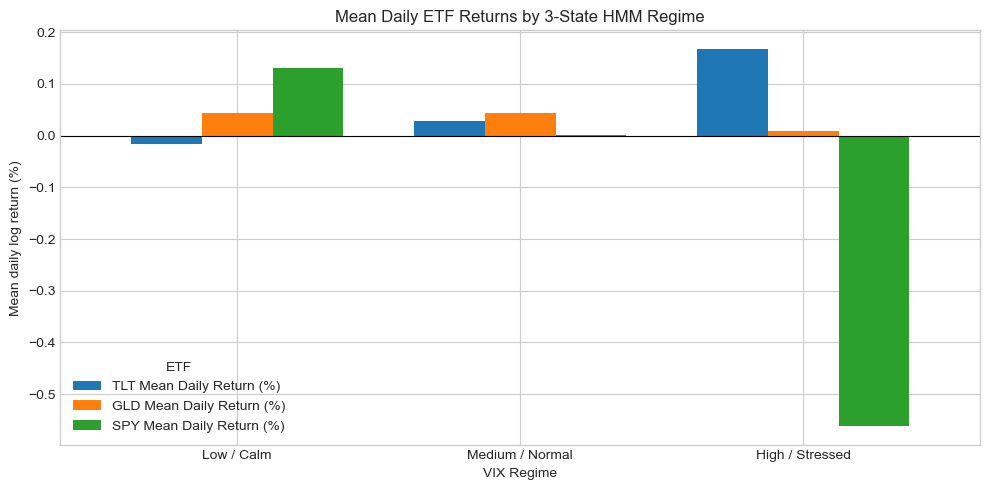

In [ ]:
mean_returns_by_state = state_conditional_returns_percent[[
    "TLT Mean Daily Return (%)",
    "GLD Mean Daily Return (%)",
    "SPY Mean Daily Return (%)",
]]

# Plotting the asset return profiles per regime
ax = mean_returns_by_state.plot(kind="bar", figsize=(10, 5), width=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean Daily ETF Returns by 3-State HMM Regime")
ax.set_xlabel("VIX Regime")
ax.set_ylabel("Mean daily log return (%)")
ax.legend(title="ETF")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Plotting ETF Volatility by Regime

Let's do the exact same thing for return volatility. This highlights the risk we absorb when we're positioned in each asset across different regimes.

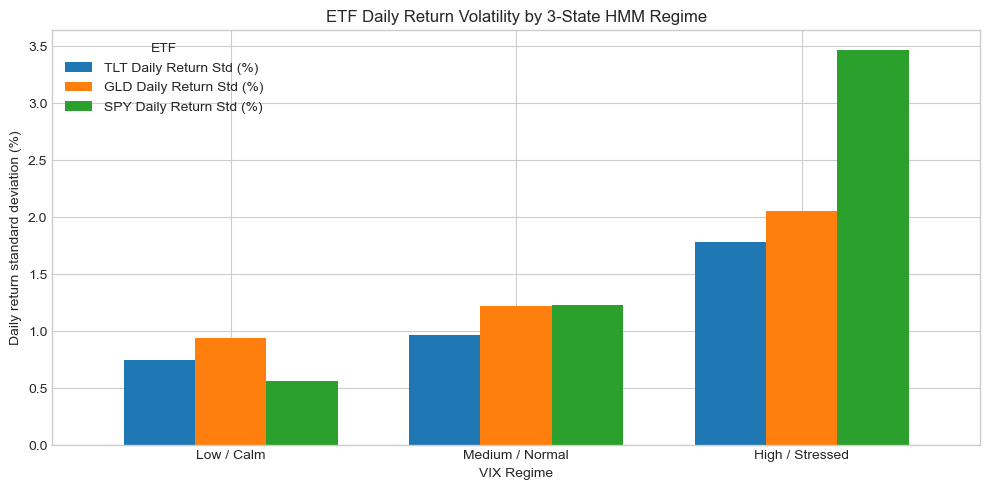

In [ ]:
return_volatility_by_state = state_conditional_returns_percent[[
    "TLT Daily Return Std (%)",
    "GLD Daily Return Std (%)",
    "SPY Daily Return Std (%)",
]]

# Plotting the risk profiles per regime
ax = return_volatility_by_state.plot(kind="bar", figsize=(10, 5), width=0.75)
ax.set_title("ETF Daily Return Volatility by 3-State HMM Regime")
ax.set_xlabel("VIX Regime")
ax.set_ylabel("Daily return standard deviation (%)")
ax.legend(title="ETF")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation of step 3

The state-conditional returns give a completely clear basis for the rotation rule.

In the Low / Calm regime, SPY has the highest average daily return, while TLT has a slightly negative average return. This supports with holding equities when volatility conditions are calm.

In the Medium / Normal regime, GLD has the highest average return, although the margin over TLT is small. This means that gold performed slightly better in this intermediate environment.

In the High / Stressed regime, TLT has the highest average return, while SPY has a strongly negative average return and much higher volatility. This supports using TLT as the defensive allocation during stressed volatility regimes.

# Step 4: Designing the Rotation Strategy

We're going to generate explicit portfolio asset weights based on our 3-state HMM signals. 

*NB:* To ensure we don't accidentally cheat by using future information, we'll apply a strict 1-day execution lag. This means that the market regime we identify at the end of today's close dictates what asset we buy and hold for the duration of tomorrow's session.

## 1. Defining the State-to-Asset Translation Map

Here is the exact mapping matrix we're hardcoding into our portfolio engine based on our historical findings:

In [ ]:
# Hardcoding our empirical asset rules into a clean dictionary list
allocation_rule = pd.DataFrame({
    "Regime": ["Low / Calm", "Medium / Normal", "High / Stressed"],
    "Selected ETF": ["SPY", "GLD", "TLT"],
    "TLT Allocation": [0.0, 0.0, 1.0],
    "GLD Allocation": [0.0, 1.0, 0.0],
    "SPY Allocation": [1.0, 0.0, 0.0],
    "Justification": [
        "SPY has the highest historical mean return in the calm state.",
        "GLD has the highest historical mean return in the normal state.",
        "TLT has the highest historical mean return, while SPY performs poorly in the stressed state.",
    ],
})

allocation_rule

,Regime,Selected ETF,TLT Allocation,GLD Allocation,SPY Allocation,Justification
0,Low / Calm,SPY,0.000000,0.000000,1.000000,SPY has the highest historical mean return in ...
1,Medium / Normal,GLD,0.000000,1.000000,0.000000,GLD has the highest historical mean return in ...
2,High / Stressed,TLT,1.000000,0.000000,0.000000,"TLT has the highest historical mean return, wh..."


## 2. Generating Unlagged Portfolio Signals

First, let's create our raw, same-day asset weight columns based on our state definitions. So we'll label these as "unlagged" since they don't have the trading execution lag applied yet.

In [ ]:
# Start with zero weight in each ETF.
strategy_data["TLT_Allocation"] = 0.0
strategy_data["GLD_Allocation"] = 0.0
strategy_data["SPY_Allocation"] = 0.0

# Fill in the ETF weight that matches each regime.
strategy_data.loc[strategy_data["HMM3_Regime"] == "Low / Calm", "SPY_Allocation"] = 1.0
strategy_data.loc[strategy_data["HMM3_Regime"] == "Medium / Normal", "GLD_Allocation"] = 1.0
strategy_data.loc[strategy_data["HMM3_Regime"] == "High / Stressed", "TLT_Allocation"] = 1.0

unlagged_allocation_columns = ["TLT_Allocation", "GLD_Allocation", "SPY_Allocation"]

strategy_data[["HMM3_Regime"] + unlagged_allocation_columns].head()

,HMM3_Regime,TLT_Allocation,GLD_Allocation,SPY_Allocation
Date,,,,
2004-11-19,Low / Calm,0.000000,0.000000,1.000000
2004-11-22,Low / Calm,0.000000,0.000000,1.000000
2004-11-23,Low / Calm,0.000000,0.000000,1.000000
2004-11-24,Low / Calm,0.000000,0.000000,1.000000
2004-11-26,Low / Calm,0.000000,0.000000,1.000000


## 3. Executing the 1-Day Forward Shift (Trading Lag)

Now we apply our execution lag. By shifting our weight signals forward by 1 trading day using `.shift(1)`, we guarantee our backtest only acts on known, historical data. Today's close signal becomes tomorrow's actual portfolio posture.

In [ ]:
lagged_allocation_columns = [
    "TLT_Allocation_Lag1",
    "GLD_Allocation_Lag1",
    "SPY_Allocation_Lag1",
]

# Shifting each allocation column forward by 1 row to enforce the execution lag
for unlagged_column, lagged_column in zip(unlagged_allocation_columns, lagged_allocation_columns):
    strategy_data[lagged_column] = strategy_data[unlagged_column].shift(1)

strategy_data[["HMM3_Regime"] + unlagged_allocation_columns + lagged_allocation_columns].head()

,HMM3_Regime,TLT_Allocation,GLD_Allocation,SPY_Allocation,TLT_Allocation_Lag1,GLD_Allocation_Lag1,SPY_Allocation_Lag1
Date,,,,,,,
2004-11-19,Low / Calm,0.000000,0.000000,1.000000,NaN,NaN,NaN
2004-11-22,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-23,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-24,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-26,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000


## 4. Validating Portfolio Constraint Weights

Let's run a quick audit on our weights. So because we're executing a full-rotation strategy, our active weights must always sum to exactly 1.0 (100% long) for every row after the initial day.

In [ ]:
lagged_weight_sum = strategy_data[lagged_allocation_columns].sum(axis=1, min_count=3)

# Auditing that our active portfolio weights always equal exactly 100% capital allocation
allocation_weight_check = pd.DataFrame({
    "Check": [
        "First row lagged weight sum",
        "Minimum lagged weight sum after first row",
        "Maximum lagged weight sum after first row",
    ],
    "Value": [
        lagged_weight_sum.iloc[0],
        lagged_weight_sum.iloc[1:].min(),
        lagged_weight_sum.iloc[1:].max(),
    ],
})

allocation_weight_check

,Check,Value
0,First row lagged weight sum,NaN
1,Minimum lagged weight sum after first row,1.000000
2,Maximum lagged weight sum after first row,1.000000


## 5. Reviewing the Consolidated Strategy Dataset

Let's review a snapshot of our unified dataframe. You can see how the 1-day lag behaves: the regime signal from day 1 becomes the active trading weight during day 2, letting us catch the actual day 2 ETF returns cleanly and fairly.

In [ ]:
sample_columns = [
    "HMM3_Regime",
    "TLT_Allocation",
    "GLD_Allocation",
    "SPY_Allocation",
    "TLT_Allocation_Lag1",
    "GLD_Allocation_Lag1",
    "SPY_Allocation_Lag1",
    "TLT_log_return",
    "GLD_log_return",
    "SPY_log_return",
]

# Printing the first 10 rows of our core strategy matrix
strategy_data[sample_columns].head(10)

,HMM3_Regime,TLT_Allocation,GLD_Allocation,SPY_Allocation,TLT_Allocation_Lag1,GLD_Allocation_Lag1,SPY_Allocation_Lag1,TLT_log_return,GLD_log_return,SPY_log_return
Date,,,,,,,,,,
2004-11-19,Low / Calm,0.000000,0.000000,1.000000,NaN,NaN,NaN,-0.008012,0.008973,-0.011179
2004-11-22,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.005198,0.003789,0.004758
2004-11-23,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.001239,-0.004459,0.001525
2004-11-24,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.006682,0.002367
2004-11-26,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-0.006551,0.005313,-0.000761
2004-11-29,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-0.010709,0.002426,-0.004573
2004-11-30,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-0.004246,-0.006187,0.000679
2004-12-01,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-0.001560,0.005746,0.011303
2004-12-02,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-0.004057,-0.009521,0.000838


## Interpretation of Step 4

The allocation table is ready for backtesting. Our first row has missing lagged weights because there is no previous-day signal yet, so the backtest begins from the second row. After that point, the lagged allocation weights sum to 1 on every trading day.

So the 1-day lag means the regime identified from one day is used for the next trading day’s allocation, which avoids using same-day information to trade same-day returns.

# Step 5: Backtesting and Evaluation

We're running our 3-state HMM regime rotation strategy through a full historical performance test, tracking our equity growth curve using our lagged execution weights.

To prove this strategy actually adds alpha, we are going to pit it against two classical industry benchmarks:
1.  Passive Buy-and-Hold S&P 500 (SPY): Just riding the stock market index.
2.  Monthly Rebalanced Equal-Weight Portfolio: A diversified benchmark that resets to an equal allocation of 33.3% TLT, 33.3% GLD, and 33.3% SPY at the start of every single month, letting the weights drift naturally within the month.

## 1. Removing the Boundary Row

Since our trading rules require a prior day's signal, row 1 doesn't have an asset allocation weight. We will drop that first row so we have a clean start for our cumulative performance tracking.

In [ ]:
# Dropping the very first row to remove the initial NaN lag row
backtest_data = strategy_data.dropna(subset=lagged_allocation_columns).copy()

print(f"Rows before removing the first missing lagged signal: {len(strategy_data):,}")
print(f"Rows used in the backtest: {len(backtest_data):,}")

backtest_data[["HMM3_Regime"] + lagged_allocation_columns].head()

Rows before removing the first missing lagged signal: 5,405
Rows used in the backtest: 5,404


,HMM3_Regime,TLT_Allocation_Lag1,GLD_Allocation_Lag1,SPY_Allocation_Lag1
Date,,,,
2004-11-22,Low / Calm,0.000000,0.000000,1.000000
2004-11-23,Low / Calm,0.000000,0.000000,1.000000
2004-11-24,Low / Calm,0.000000,0.000000,1.000000
2004-11-26,Low / Calm,0.000000,0.000000,1.000000
2004-11-29,Low / Calm,0.000000,0.000000,1.000000


## 2. Calculating Daily Portfolio and Benchmark Returns

Time to calculate daily performance. Our rotation strategy's daily log return is simply the dot product of our active asset weights multiplied by their respective log returns:
$$\text{Strategy Return} = w_{\text{TLT}} \cdot R_{\text{TLT}} + w_{\text{GLD}} \cdot R_{\text{GLD}} + w_{\text{SPY}} \cdot R_{\text{SPY}}$$

For our equal-weight benchmark, we'll write a tracking loop that resets asset allocations back to a perfect $1/3$ split on the first day of every month, letting the portfolio value drift naturally day-by-day in between rebalancings.

In [ ]:
backtest_data["Rotation_Strategy_log_return"] = (
    backtest_data["TLT_Allocation_Lag1"] * backtest_data["TLT_log_return"]
    + backtest_data["GLD_Allocation_Lag1"] * backtest_data["GLD_log_return"]
    + backtest_data["SPY_Allocation_Lag1"] * backtest_data["SPY_log_return"]
)

# Calculating the daily log returns for the SPY Buy-and-Hold strategy
backtest_data["SPY_BuyHold_log_return"] = backtest_data["SPY_log_return"]

# Converting log returns to simple returns for our equal-weight rebalancing loops
asset_log_returns = backtest_data[["TLT_log_return", "GLD_log_return", "SPY_log_return"]]
asset_simple_returns = np.exp(asset_log_returns) - 1
asset_simple_returns.columns = ["TLT", "GLD", "SPY"]

equal_weight_simple_returns = []
current_month = None
weights = np.array([1/3, 1/3, 1/3])

# Simulating the monthly rebalancing process day-by-day
for date, daily_returns in asset_simple_returns.iterrows():
    month = date.to_period("M")

    if current_month is None or month != current_month:
        weights = np.array([1/3, 1/3, 1/3])
        current_month = month

    daily_returns_array = daily_returns.values
    portfolio_simple_return = np.dot(weights, daily_returns_array)
    equal_weight_simple_returns.append(portfolio_simple_return)

    # Letting the internal portfolio weights drift with daily price performance
    weights = weights * (1 + daily_returns_array) / (1 + portfolio_simple_return)

backtest_data["EqualWeight_Monthly_Rebalanced_simple_return"] = equal_weight_simple_returns
backtest_data["EqualWeight_Monthly_Rebalanced_log_return"] = np.log1p(
    backtest_data["EqualWeight_Monthly_Rebalanced_simple_return"]
)

return_sample_columns = [
    "Rotation_Strategy_log_return",
    "EqualWeight_Monthly_Rebalanced_log_return",
    "SPY_BuyHold_log_return",
]

backtest_data[return_sample_columns].head()

,Rotation_Strategy_log_return,EqualWeight_Monthly_Rebalanced_log_return,SPY_BuyHold_log_return
Date,,,
2004-11-22,0.004758,0.004582,0.004758
2004-11-23,0.001525,-0.000560,0.001525
2004-11-24,0.002367,0.003011,0.002367
2004-11-26,-0.000761,-0.000655,-0.000761
2004-11-29,-0.004573,-0.004246,-0.004573


## 3. Calculating the Cumulative Wealth Growth Curves

Since we are working with log returns, we can easily calculate cumulative portfolio values over time by taking the exponential sum of our daily return streams:

`cumulative wealth = exp(cumulative sum of log returns)`

We'll assume an initial investment baseline of $1.00 for all three paths so they grow on a standardized scale.

In [ ]:
# Calculating cumulative exponential returns for our growth chart
wealth_curves = np.exp(backtest_data[[
    "Rotation_Strategy_log_return",
    "EqualWeight_Monthly_Rebalanced_log_return",
    "SPY_BuyHold_log_return",
]].cumsum())

wealth_curves = wealth_curves.rename(columns={
    "Rotation_Strategy_log_return": "Regime Rotation Strategy",
    "EqualWeight_Monthly_Rebalanced_log_return": "Equal-Weight Benchmark",
    "SPY_BuyHold_log_return": "Buy-and-Hold SPY",
})

display(wealth_curves.head())
display(wealth_curves.tail())

,Regime Rotation Strategy,Equal-Weight Benchmark,Buy-and-Hold SPY
Date,,,
2004-11-22,1.004769,1.004592,1.004769
2004-11-23,1.006302,1.004030,1.006302
2004-11-24,1.008687,1.007058,1.008687
2004-11-26,1.007920,1.006398,1.007920
2004-11-29,1.003321,1.002134,1.003321


,Regime Rotation Strategy,Equal-Weight Benchmark,Buy-and-Hold SPY
Date,,,
2026-05-11,39.855784,6.534090,9.350898
2026-05-12,39.795405,6.507804,9.336732
2026-05-13,40.018054,6.503069,9.388969
2026-05-14,40.333967,6.506905,9.463088
2026-05-15,39.848776,6.398542,9.349253


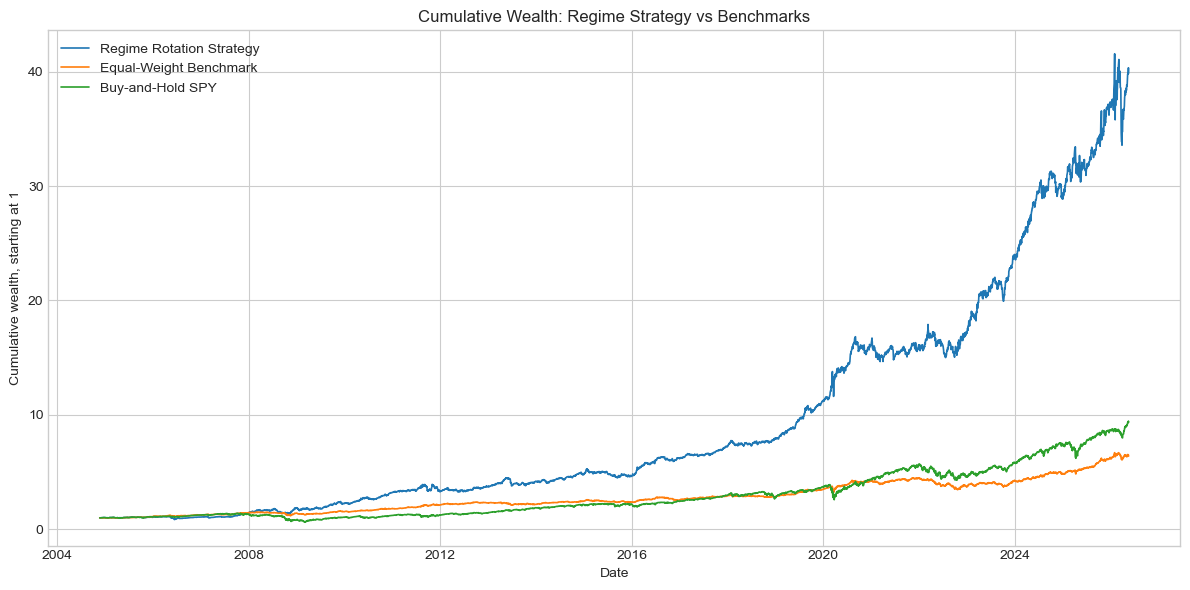

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for column in wealth_curves.columns:
    ax.plot(wealth_curves.index, wealth_curves[column], label=column, linewidth=1.2)

ax.set_title("Cumulative Wealth: Regime Strategy vs Benchmarks")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative wealth, starting at 1")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Generating Performance Performance Metrics

We use 252 trading days per year for annualization. The Sharpe ratio assumes a zero risk-free rate.

In [ ]:
def calculate_max_drawdown(wealth_series):
    running_max = wealth_series.cummax()
    drawdown = wealth_series / running_max - 1
    return drawdown.min()


def calculate_performance_metrics(log_return_series):
    wealth_series = np.exp(log_return_series.cumsum())
    cumulative_return = wealth_series.iloc[-1] - 1
    annualized_return = np.exp(log_return_series.mean() * 252) - 1
    annualized_volatility = log_return_series.std() * np.sqrt(252)
    sharpe_ratio = (log_return_series.mean() / log_return_series.std()) * np.sqrt(252)
    max_drawdown = calculate_max_drawdown(wealth_series)

    return pd.Series({
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
    })

performance_summary = pd.DataFrame({
    "Regime Rotation Strategy": calculate_performance_metrics(backtest_data["Rotation_Strategy_log_return"]),
    "Equal-Weight Benchmark": calculate_performance_metrics(backtest_data["EqualWeight_Monthly_Rebalanced_log_return"]),
    "Buy-and-Hold SPY": calculate_performance_metrics(backtest_data["SPY_BuyHold_log_return"]),
}).T

performance_summary

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Regime Rotation Strategy,38.848776,0.187492,0.154609,1.111470,-0.240096
Equal-Weight Benchmark,5.398542,0.090409,0.096849,0.893685,-0.230437
Buy-and-Hold SPY,8.349253,0.109863,0.189448,0.550211,-0.551894


## 5. Clean Performance Summary Table

This table shows returns, volatility, and drawdown in percentage terms. The Sharpe ratio is kept as a regular ratio.

In [ ]:
performance_summary_display = performance_summary.copy()
percent_metric_columns = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
]
performance_summary_display[percent_metric_columns] = 100 * performance_summary_display[percent_metric_columns]

performance_summary_display = performance_summary_display.rename(columns={
    "Cumulative Return": "Cumulative Return (%)",
    "Annualized Return": "Annualized Return (%)",
    "Annualized Volatility": "Annualized Volatility (%)",
    "Max Drawdown": "Max Drawdown (%)",
})

performance_summary_display

,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
Regime Rotation Strategy,"3,884.877566",18.749216,15.460929,1.111470,-24.009563
Equal-Weight Benchmark,539.854180,9.040860,9.684904,0.893685,-23.043657
Buy-and-Hold SPY,834.925322,10.986304,18.944837,0.550211,-55.189442


## 6. Direct Comparison Checks

This table gives a simple yes-or-no comparison of the regime rotation strategy against the two benchmarks.

In [ ]:
comparison_checks = pd.DataFrame({
    "Question": [
        "Did the regime strategy beat SPY on cumulative return?",
        "Did the regime strategy beat equal-weight on cumulative return?",
        "Did the regime strategy have lower volatility than SPY?",
        "Did the regime strategy have a smaller drawdown than SPY?",
        "Did the regime strategy have a higher Sharpe ratio than SPY?",
    ],
    "Answer": [
        performance_summary.loc["Regime Rotation Strategy", "Cumulative Return"] > performance_summary.loc["Buy-and-Hold SPY", "Cumulative Return"],
        performance_summary.loc["Regime Rotation Strategy", "Cumulative Return"] > performance_summary.loc["Equal-Weight Benchmark", "Cumulative Return"],
        performance_summary.loc["Regime Rotation Strategy", "Annualized Volatility"] < performance_summary.loc["Buy-and-Hold SPY", "Annualized Volatility"],
        performance_summary.loc["Regime Rotation Strategy", "Max Drawdown"] > performance_summary.loc["Buy-and-Hold SPY", "Max Drawdown"],
        performance_summary.loc["Regime Rotation Strategy", "Sharpe Ratio"] > performance_summary.loc["Buy-and-Hold SPY", "Sharpe Ratio"],
    ],
})

comparison_checks["Answer"] = comparison_checks["Answer"].map({True: "Yes", False: "No"})
comparison_checks

,Question,Answer
0,Did the regime strategy beat SPY on cumulative...,Yes
1,Did the regime strategy beat equal-weight on c...,Yes
2,Did the regime strategy have lower volatility ...,Yes
3,Did the regime strategy have a smaller drawdow...,Yes
4,Did the regime strategy have a higher Sharpe r...,Yes


## Interpretation of Step 5

The 3-state regime rotation strategy performed well over the historical sample. It produced the highest cumulative return (3,884.83%), annualized return, and Sharpe ratio among the main three strategies, and it reduced drawdown substantially compared with buy-and-hold SPY.

The equal-weight benchmark had the lowest volatility and a slightly smaller maximum drawdown, but its return was much lower. SPY produced a higher return than equal-weight, but with the largest drawdown and the weakest Sharpe ratio.

These results suggest that VIX-based regimes can be useful for changing portfolio exposure across assets but the strategy should be interpreted properly because the HMM was fitted on the full historical sample. A live implementation would need us to do rolling or expanding-window estimation, transaction costs, and further out-of-sample testing.

# Step 5.2: Sensitivity Check (The 2-State HMM Strategy)

To round out our project, let's run a quick sensitivity check. We want to test if the extra complexity of our 3-state HMM was actually worth it, or if a simpler, stripped-down 2-state HMM strategy can generate the exact same results. 

We'll replicate our entire strategy engineering workflow using our 2-state HMM labels from Step 2 to see how the performance holds up.

## 5.2.1. Profiling ETF Performance in the 2-State World

Let's group our daily ETF return data by our 2-state HMM labels to see how the assets trend when we only give the model two options (Calm vs. Stressed)

In [ ]:
hmm2_regime_order = ["Low / Calm", "High / Stressed"]

# Calculating the mean log returns across our 2-state configurations
hmm2_conditional_mean_returns = (
    strategy_data
    .groupby("HMM2_Regime")[["TLT_log_return", "GLD_log_return", "SPY_log_return"]]
    .mean()
    .reindex(hmm2_regime_order)
)

hmm2_conditional_mean_returns

,TLT_log_return,GLD_log_return,SPY_log_return
HMM2_Regime,,,
Low / Calm,-0.000139,0.000342,0.001201
High / Stressed,0.000937,0.000645,-0.002102


In [ ]:
# Identifying the winning asset ticker for each of our two states
hmm2_best_etf_by_state = (
    hmm2_conditional_mean_returns
    .idxmax(axis=1)
    .str.replace("_log_return", "", regex=False)
)

hmm2_best_etf_by_state.to_frame("Selected ETF")

,Selected ETF
HMM2_Regime,
Low / Calm,SPY
High / Stressed,TLT


## 5.2.2. Hardcoding the 2-State Asset Allocation Rules

Just like before, we'll map our state-conditional winners into portfolio asset allocation weights (100% SPY when calm, 100% TLT when stressed):

In [ ]:
hmm2_allocation_mapping = []

# Formatting the 2-state strategy rules matrix
for regime in hmm2_regime_order:
    selected_etf = hmm2_best_etf_by_state.loc[regime]
    hmm2_allocation_mapping.append({
        "Regime": regime,
        "Selected ETF": selected_etf,
        "TLT Allocation": 1.0 if selected_etf == "TLT" else 0.0,
        "GLD Allocation": 1.0 if selected_etf == "GLD" else 0.0,
        "SPY Allocation": 1.0 if selected_etf == "SPY" else 0.0,
        "Justification": f"{selected_etf} has the highest historical mean return in this 2-state regime.",
    })

hmm2_allocation_mapping = pd.DataFrame(hmm2_allocation_mapping)
hmm2_allocation_mapping

,Regime,Selected ETF,TLT Allocation,GLD Allocation,SPY Allocation,Justification
0,Low / Calm,SPY,0.000000,0.000000,1.000000,SPY has the highest historical mean return in ...
1,High / Stressed,TLT,1.000000,0.000000,0.000000,TLT has the highest historical mean return in ...


## 5.2.3. Creating Lagged 2-State Allocations

Let's build out our allocation weight columns and enforce our strict 1-day forward execution lag using `.shift(1)` to keep the backtest entirely honest and clean

In [ ]:
hmm2_allocation_columns = [
    "HMM2_TLT_Allocation",
    "HMM2_GLD_Allocation",
    "HMM2_SPY_Allocation",
]

# Setting our baseline weights to 0.0
strategy_data[hmm2_allocation_columns] = 0.0

for regime in hmm2_regime_order:
    selected_etf = hmm2_best_etf_by_state.loc[regime]
    allocation_column = f"HMM2_{selected_etf}_Allocation"
    strategy_data.loc[strategy_data["HMM2_Regime"] == regime, allocation_column] = 1.0

hmm2_lagged_allocation_columns = [
    "HMM2_TLT_Allocation_Lag1",
    "HMM2_GLD_Allocation_Lag1",
    "HMM2_SPY_Allocation_Lag1",
]

# Applying the 1-day lag to our allocation columns
for allocation_column, lagged_column in zip(hmm2_allocation_columns, hmm2_lagged_allocation_columns):
    strategy_data[lagged_column] = strategy_data[allocation_column].shift(1)

strategy_data[["HMM2_Regime"] + hmm2_allocation_columns + hmm2_lagged_allocation_columns].head()

,HMM2_Regime,HMM2_TLT_Allocation,HMM2_GLD_Allocation,HMM2_SPY_Allocation,HMM2_TLT_Allocation_Lag1,HMM2_GLD_Allocation_Lag1,HMM2_SPY_Allocation_Lag1
Date,,,,,,,
2004-11-19,Low / Calm,0.000000,0.000000,1.000000,NaN,NaN,NaN
2004-11-22,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-23,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-24,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2004-11-26,Low / Calm,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000


## 5.2.4. Backtest the 2-State Regime Strategy

We use the same backtest dates as the main 3-state strategy so the comparison is fair.

In [ ]:
sensitivity_data = strategy_data.loc[backtest_data.index].copy()

# Calculating the daily log returns for the 2-state strategy
backtest_data["Two_State_Rotation_log_return"] = (
    sensitivity_data["HMM2_TLT_Allocation_Lag1"] * sensitivity_data["TLT_log_return"]
    + sensitivity_data["HMM2_GLD_Allocation_Lag1"] * sensitivity_data["GLD_log_return"]
    + sensitivity_data["HMM2_SPY_Allocation_Lag1"] * sensitivity_data["SPY_log_return"]
)

print(f"Rows used in the 2-state sensitivity backtest: {backtest_data['Two_State_Rotation_log_return'].dropna().shape[0]:,}")
backtest_data[["Rotation_Strategy_log_return", "Two_State_Rotation_log_return"]].head()

Rows used in the 2-state sensitivity backtest: 5,404


,Rotation_Strategy_log_return,Two_State_Rotation_log_return
Date,,
2004-11-22,0.004758,0.004758
2004-11-23,0.001525,0.001525
2004-11-24,0.002367,0.002367
2004-11-26,-0.000761,-0.000761
2004-11-29,-0.004573,-0.004573


## 5.2.5 Merging All Performance Curves

Let's pass our new 2-state return stream through our performance summary engine and append the results alongside our 3-state strategy and baseline market benchmarks.

In [ ]:
performance_summary_with_2state = pd.DataFrame({
    "3-State Regime Strategy": calculate_performance_metrics(backtest_data["Rotation_Strategy_log_return"]),
    "2-State Regime Strategy": calculate_performance_metrics(backtest_data["Two_State_Rotation_log_return"]),
    "Equal-Weight Benchmark": calculate_performance_metrics(backtest_data["EqualWeight_Monthly_Rebalanced_log_return"]),
    "Buy-and-Hold SPY": calculate_performance_metrics(backtest_data["SPY_BuyHold_log_return"]),
}).T

performance_summary_with_2state

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
3-State Regime Strategy,38.848776,0.187492,0.154609,1.111470,-0.240096
2-State Regime Strategy,44.983868,0.195448,0.142357,1.254037,-0.195403
Equal-Weight Benchmark,5.398542,0.090409,0.096849,0.893685,-0.230437
Buy-and-Hold SPY,8.349253,0.109863,0.189448,0.550211,-0.551894


In [ ]:
performance_summary_with_2state_display = performance_summary_with_2state.copy()
performance_summary_with_2state_display[percent_metric_columns] = 100 * performance_summary_with_2state_display[percent_metric_columns]

performance_summary_with_2state_display = performance_summary_with_2state_display.rename(columns={
    "Cumulative Return": "Cumulative Return (%)",
    "Annualized Return": "Annualized Return (%)",
    "Annualized Volatility": "Annualized Volatility (%)",
    "Max Drawdown": "Max Drawdown (%)",
})

performance_summary_with_2state_display

,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
3-State Regime Strategy,"3,884.877566",18.749216,15.460929,1.111470,-24.009563
2-State Regime Strategy,"4,498.386803",19.544838,14.235731,1.254037,-19.540273
Equal-Weight Benchmark,539.854180,9.040860,9.684904,0.893685,-23.043657
Buy-and-Hold SPY,834.925322,10.986304,18.944837,0.550211,-55.189442


## 5.2.6. Cumulative Wealth Comparison

So this plot compares the 3-state strategy, the 2-state strategy, the equal-weight benchmark, and buy-and-hold SPY.

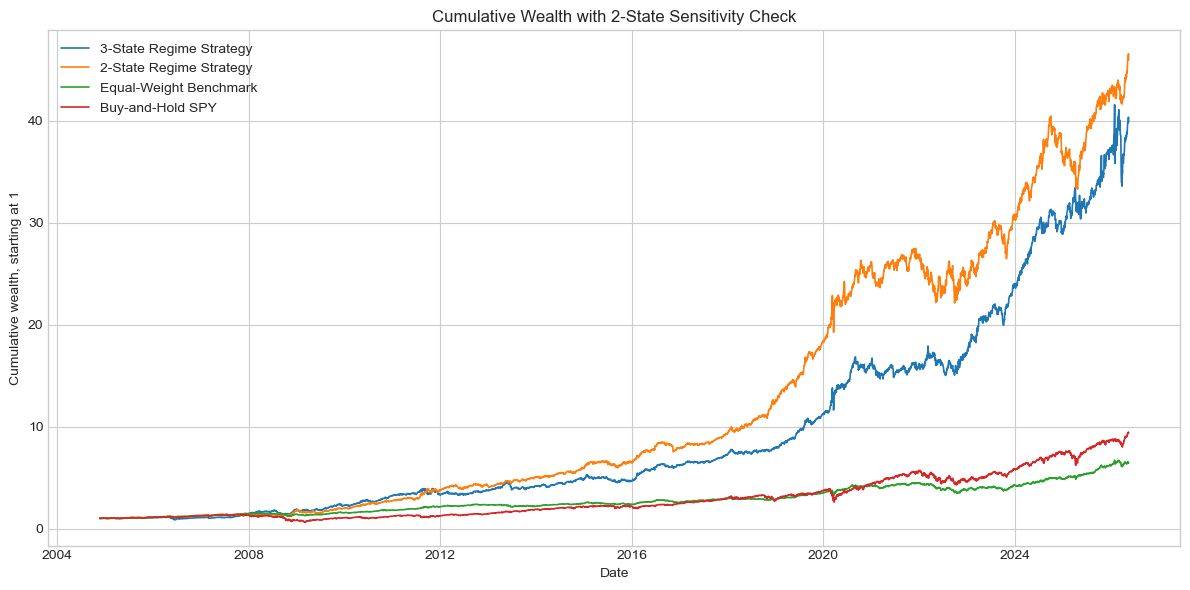

In [ ]:
# Calculating cumulative growth paths for our final summary chart
wealth_curves_with_2state = np.exp(backtest_data[[
    "Rotation_Strategy_log_return",
    "Two_State_Rotation_log_return",
    "EqualWeight_Monthly_Rebalanced_log_return",
    "SPY_BuyHold_log_return",
]].cumsum())

wealth_curves_with_2state = wealth_curves_with_2state.rename(columns={
    "Rotation_Strategy_log_return": "3-State Regime Strategy",
    "Two_State_Rotation_log_return": "2-State Regime Strategy",
    "EqualWeight_Monthly_Rebalanced_log_return": "Equal-Weight Benchmark",
    "SPY_BuyHold_log_return": "Buy-and-Hold SPY",
})

fig, ax = plt.subplots(figsize=(12, 6))

for column in wealth_curves_with_2state.columns:
    ax.plot(wealth_curves_with_2state.index, wealth_curves_with_2state[column], label=column, linewidth=1.2)

ax.set_title("Cumulative Wealth with 2-State Sensitivity Check")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative wealth, starting at 1")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Sensitivity Interpretation

Our sensitivity check revealed that the simpler 2-state regime strategy performed better than the 3-state version in the backtest. Even though the 3-state HMM had better AIC and BIC, the 2-state strategy gave us a higher cumulative return, higher annualized return, higher Sharpe ratio, and a smaller maximum drawdown.

This tells us that the main investment value may come from the broad distinction between calm and stressed volatility conditions. The 3-state model gives a richer description of how VIX behaves, but the extra medium state does not improve the trading rule in this sample.

Because of that, the 3-state HMM remains useful for regime interpretation, while the 2-state strategy is a strong practical candidate for implementation.

## Step 1 Interpretation

The ETF return plots show that returns are centered around zero most of the time, but the size of daily moves changes a lot through time. This is the usual volatility clustering we expect in financial data: calm periods are followed by calm periods, and stress periods tend to have several large moves close together.

The VIX change plot shows sharp spikes during market stress. These spikes are useful for the next steps because they give a simple way to identify changes in the volatility environment. The cleaned data set is now ready for regime classification and strategy backtesting, where we will make sure to lag signals by one day before using them in allocation decisions.
